In [624]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/housing-price-prediction/Housing.csv


In [625]:
import pandas as pd
df=pd.read_csv("/kaggle/input/housing-price-prediction/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [626]:
df.shape

(545, 13)

In [627]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [628]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [629]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


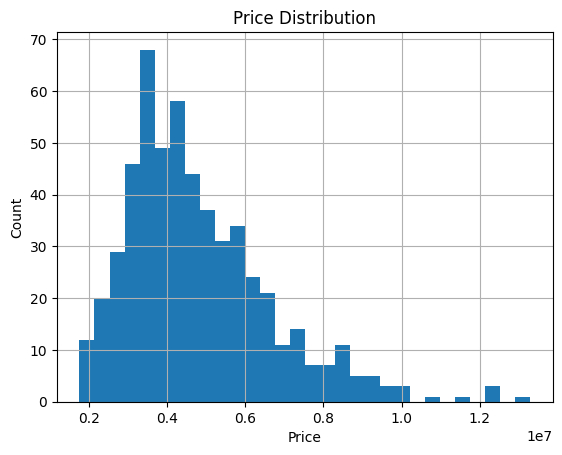

In [630]:
 import matplotlib.pyplot as plt

df['price'].hist(bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

In [631]:
y=df["price"]

In [632]:
y_log = np.log1p(y)
##as the data is right skewed  we do the log transform to normalize it

In [633]:
import numpy as np

df["price"] = np.log(df["price"])

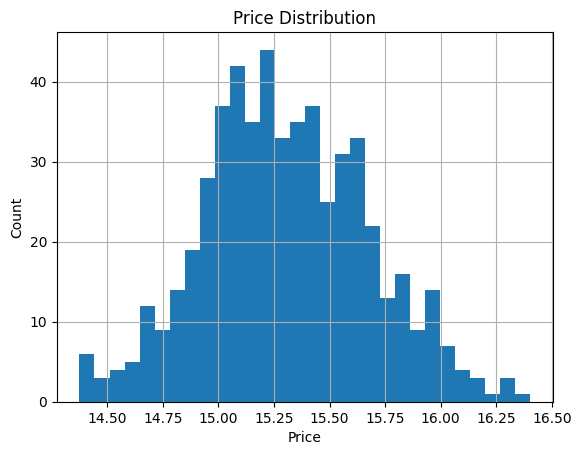

In [634]:
df['price'].hist(bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

In [635]:
# print("the shape of x is",x.shape)
# print("the shape of y is",y.shape)

In [636]:
x.dtypes

area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [637]:
#making the both bedroom and bathroom to single coloumn
df["total_room"] = df["bedrooms"] + df["bathrooms"]
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_room
0,16.403275,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,6
1,16.321036,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,8
2,16.321036,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,5
3,16.318175,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,6
4,16.250001,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,5


In [638]:
df.drop(["bedrooms", "bathrooms"], axis=1, inplace=True)
#dropping the combined colmn.

In [639]:
df.head()

,price,area,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_room
0,16.403275,7420,3,yes,no,no,no,yes,2,yes,furnished,6
1,16.321036,8960,4,yes,no,no,no,yes,3,no,furnished,8
2,16.321036,9960,2,yes,no,yes,no,no,2,yes,semi-furnished,5
3,16.318175,7500,2,yes,no,yes,no,yes,3,yes,furnished,6
4,16.250001,7420,2,yes,yes,yes,no,yes,2,no,furnished,5


In [640]:
cols = ['mainroad','guestroom','basement','hotwaterheating','airconditioning','prefarea']
df[cols] = df[cols].replace({'yes':1, 'no':0})

/tmp/ipykernel_55/2999727786.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols] = df[cols].replace({'yes':1, 'no':0})


In [641]:
df.head()

,price,area,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_room
0,16.403275,7420,3,1,0,0,0,1,2,1,furnished,6
1,16.321036,8960,4,1,0,0,0,1,3,0,furnished,8
2,16.321036,9960,2,1,0,1,0,0,2,1,semi-furnished,5
3,16.318175,7500,2,1,0,1,0,1,3,1,furnished,6
4,16.250001,7420,2,1,1,1,0,1,2,0,furnished,5


In [642]:
print(df["furnishingstatus"].unique())
#checking the unique values

['furnished' 'semi-furnished' 'unfurnished']


In [643]:
print(df.columns)


Index(['price', 'area', 'stories', 'mainroad', 'guestroom', 'basement',
       'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus', 'total_room'],
      dtype='object')


In [644]:
df.columns = df.columns.str.strip()

In [645]:
df = pd.get_dummies(
    df,
    columns=["furnishingstatus"],
    drop_first=True,
    dtype=int
)

In [646]:
df.head()

,price,area,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,total_room,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,16.403275,7420,3,1,0,0,0,1,2,1,6,0,0
1,16.321036,8960,4,1,0,0,0,1,3,0,8,0,0
2,16.321036,9960,2,1,0,1,0,0,2,1,5,1,0
3,16.318175,7500,2,1,0,1,0,1,3,1,6,0,0
4,16.250001,7420,2,1,1,1,0,1,2,0,5,0,0


In [647]:
df = pd.get_dummies(df, columns=["stories"], drop_first=True, dtype=int)

In [648]:
df.head()

,price,area,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,total_room,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,stories_2,stories_3,stories_4
0,16.403275,7420,1,0,0,0,1,2,1,6,0,0,0,1,0
1,16.321036,8960,1,0,0,0,1,3,0,8,0,0,0,0,1
2,16.321036,9960,1,0,1,0,0,2,1,5,1,0,1,0,0
3,16.318175,7500,1,0,1,0,1,3,1,6,0,0,1,0,0
4,16.250001,7420,1,1,1,0,1,2,0,5,0,0,1,0,0


In [649]:
df.shape

(545, 15)

In [650]:
X = df.drop("price", axis=1)
y = df["price"]

In [651]:
print(X.shape)
print(y.shape)

(545, 14)
(545,)


In [652]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

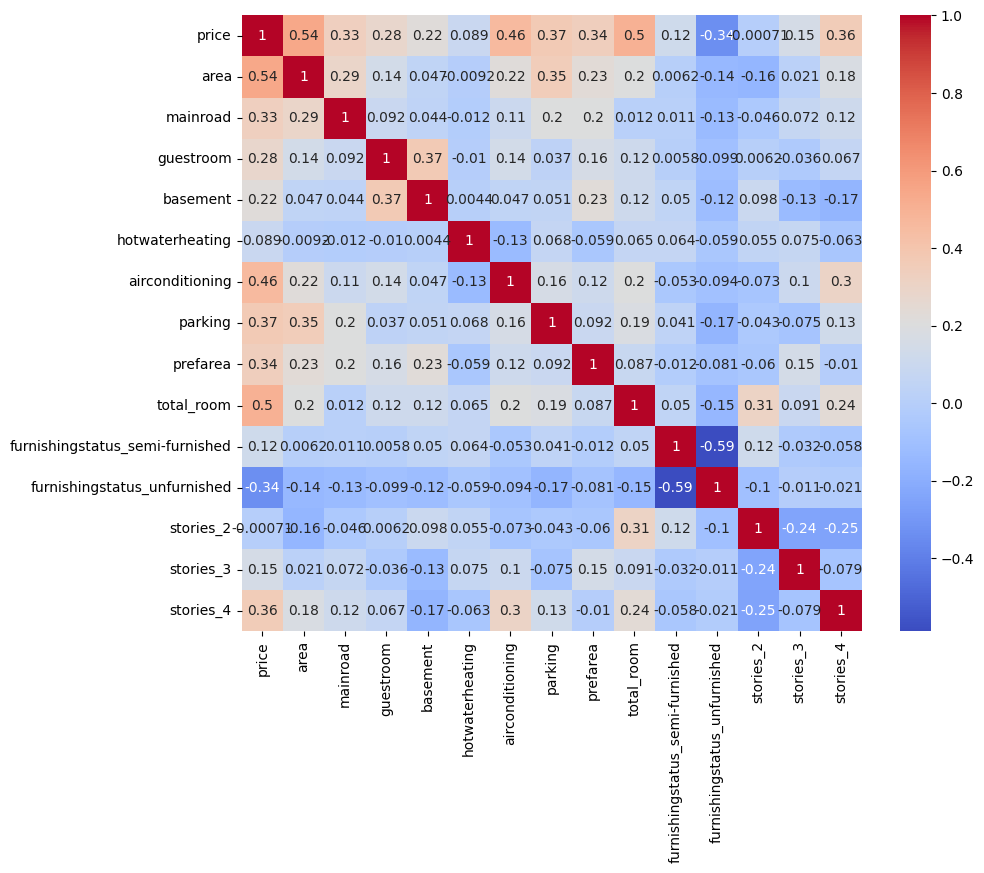

In [653]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [654]:
##applying linear regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Scaled Linear R2:", model.score(X_test_scaled, y_test))

Scaled Linear R2: 0.6709558329001315


In [655]:
##applying random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.5953243603010092


In [656]:
##ridge regression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

scaler = StandardScaler()

# Scale properly
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))

Ridge R2: 0.6707637689758565


In [657]:
print(X.shape)
print(y.shape)

(545, 14)
(545,)


In [658]:
print(y.describe())

count    545.000000
mean      15.306987
std        0.372165
min       14.375126
25%       15.048071
50%       15.283385
75%       15.562970
max       16.403275
Name: price, dtype: float64


In [659]:
print(X.isnull().sum().sum())

0


In [660]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

print("All fold scores:", scores)
print("Average CV R2:", scores.mean())

All fold scores: [0.67095583 0.69728808 0.52546616 0.7217683  0.64546539]
Average CV R2: 0.6521887526922063


In [661]:
import pandas as pd

new_house = pd.DataFrame([{
    'area': 8000,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 1,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking': 2,
    'prefarea': 1,
    'total_room': 6,
    'furnishingstatus_semi-furnished': 0,
    'furnishingstatus_unfurnished': 1,
    'stories_2': 0,
    'stories_3': 1,
    'stories_4': 0
}])

In [662]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

prediction_log = pipeline.predict(new_house)
prediction_price = np.exp(prediction_log)

print("Predicted Price:", prediction_price[0])

Predicted Price: 8168005.1035852125
